In [1]:
%cd ..

/home/bhchen/LearnKalmanGain


In [2]:
import torch
import matplotlib.pyplot as plt
import os
import pandas as pd

In [3]:
methods = ['EnKF', 'LETKF']
benchmark_W2_diff = {'GT': 1.837}

for method in methods:
    path = f"save/grid_search_linear_1.0_{method}"
    data_path = os.path.join(path, "best_output_10.pt")
    benchmark_data = torch.load(data_path, weights_only=True)
    benchmark_W2_diff[method] = benchmark_data['best_metrics']['mean_w2_diff']

for key, value in benchmark_W2_diff.items():
    print(f"{key}: {value}")

GT: 1.837
EnKF: 2.3909130096435547
LETKF: 2.493105888366699


Processing LR: 1e-2...
  Saved plot to save/figures/linear_gaussian_w2diff_1e-2.pdf


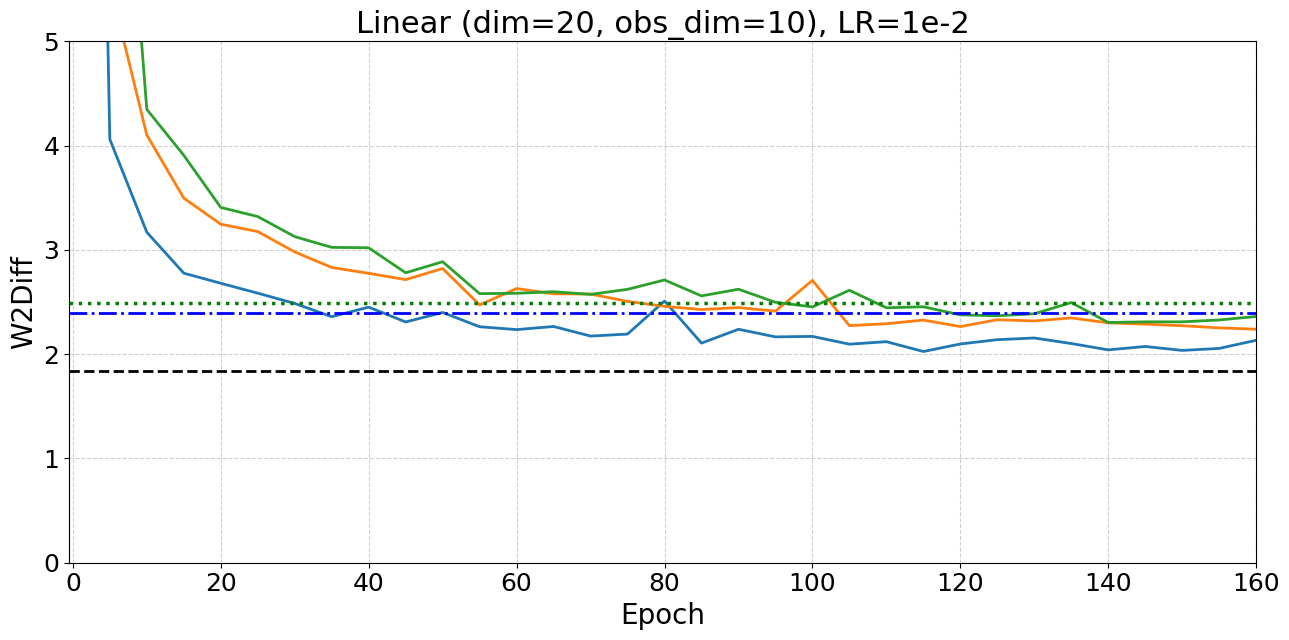

Processing LR: 5e-3...
  Saved plot to save/figures/linear_gaussian_w2diff_5e-3.pdf


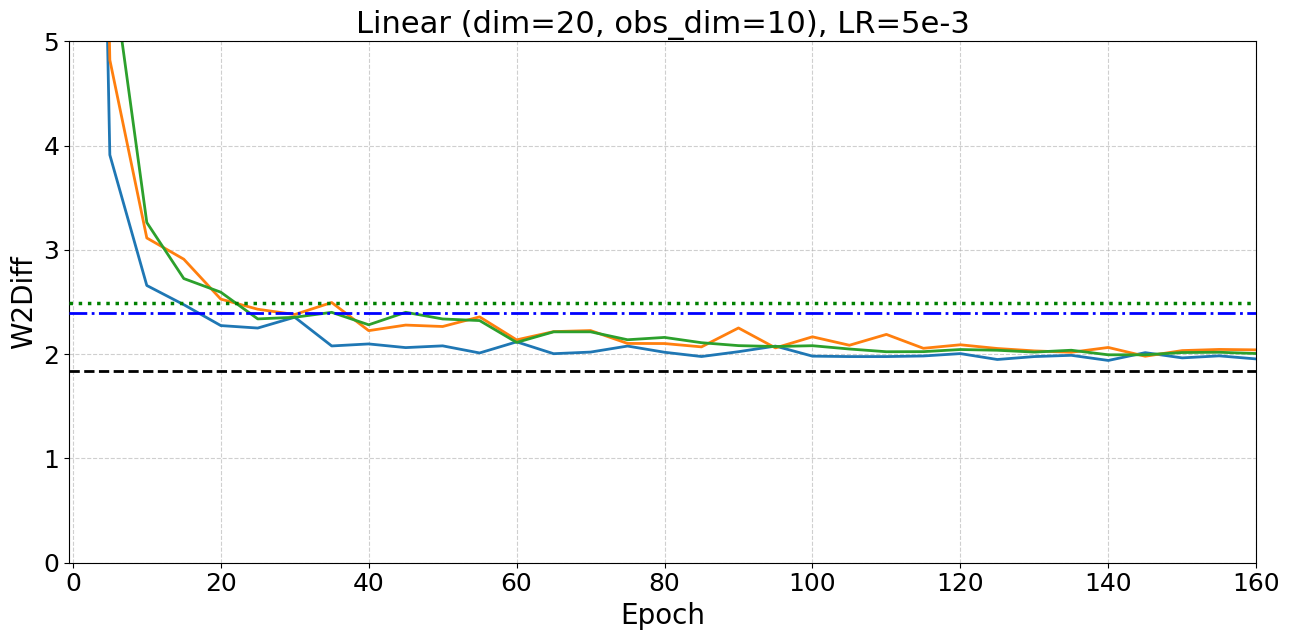

Processing LR: 1e-3...
  Saved plot to save/figures/linear_gaussian_w2diff_1e-3.pdf


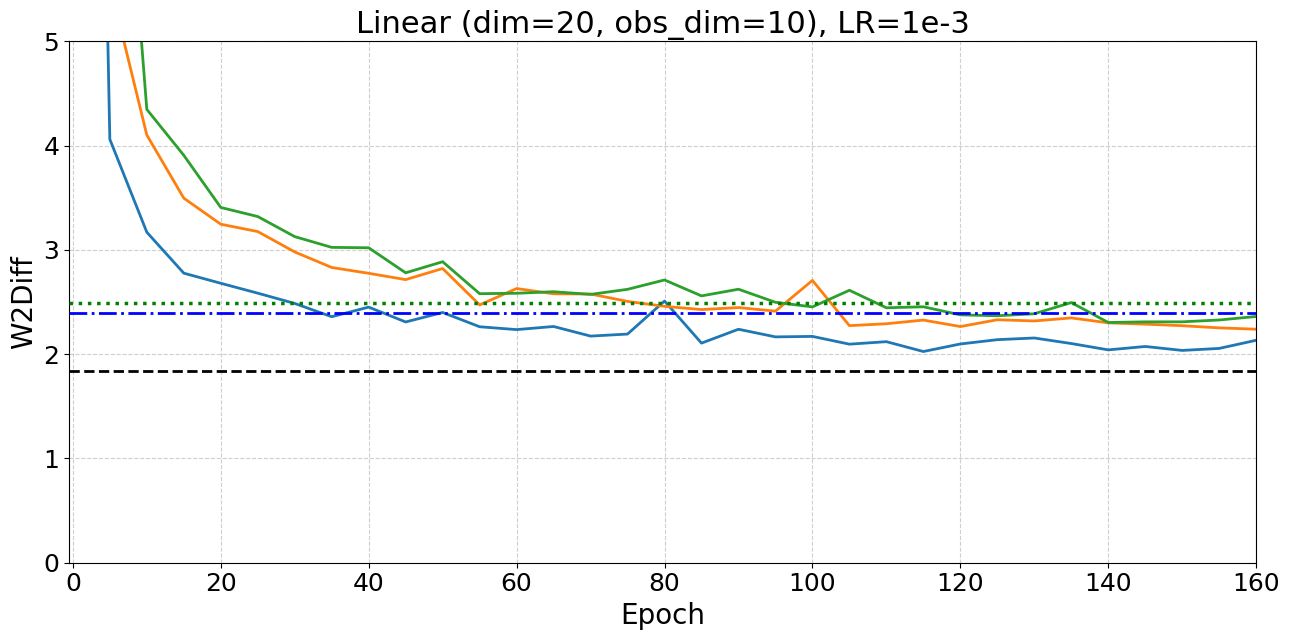

Processing LR: 5e-4...
  Saved plot to save/figures/linear_gaussian_w2diff_5e-4.pdf


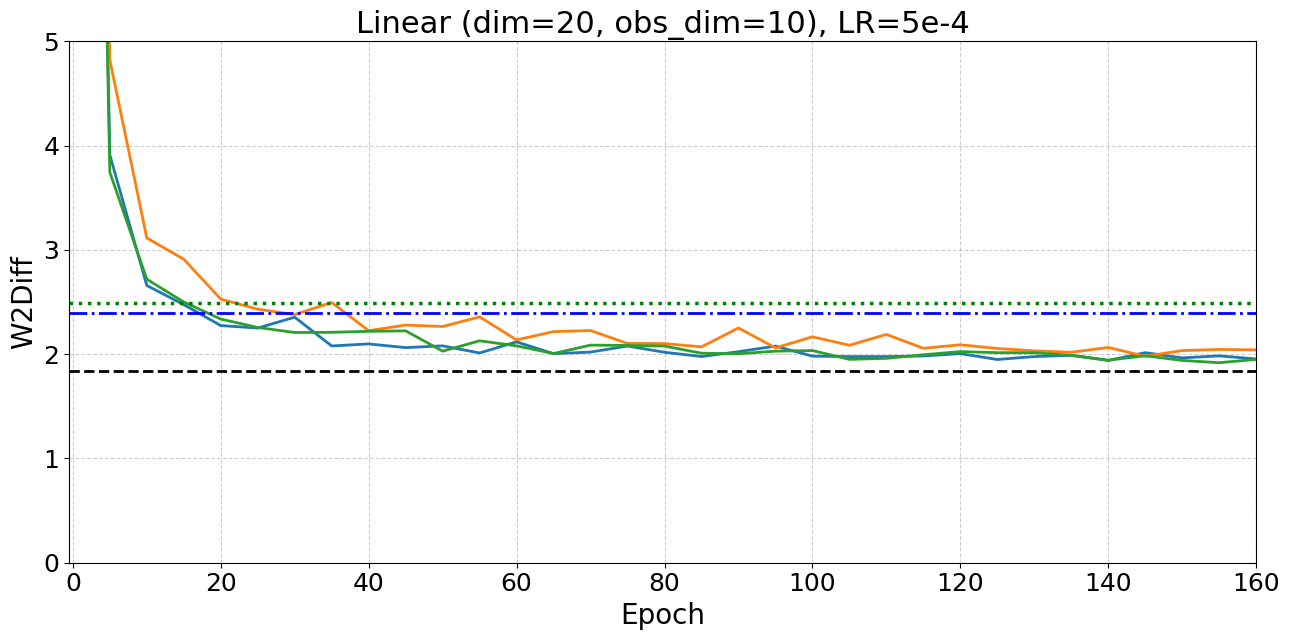

Saved corrected legend to save/figures/linear_gaussian_w2diff_legend.pdf


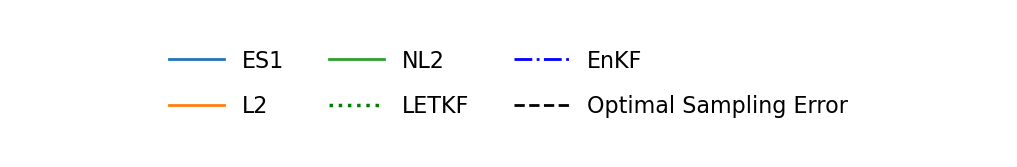

In [4]:
import torch
import os
import matplotlib.pyplot as plt
import numpy as np

# =================== Style & layout knobs ===================
FIGSIZE_MAIN = (13, 6.5)
FIGSIZE_LEGEND = (10, 1.5) # Adjusted height

# Line Styles
MAIN_LINE_WIDTH = 2.0
GT_COLOR, GT_LS, GT_LW, GT_LABEL = "k", "--", 2.0, "Optimal Sampling Error"
ENKF_COLOR, ENKF_LS, ENKF_LW, ENKF_LABEL = "blue", "-.", 2.0, "EnKF"
LETKF_COLOR, LETKF_LS, LETKF_LW, LETKF_LABEL = "green", ":", 2.5, "LETKF"

# Axes & Grid
X_LIM = (-0.5, 160) # CHANGED: Limit to 150 epochs
Y_LIM = (0, 5)
GRID_LS = "--"
GRID_ALPHA = 0.6

# Font sizes
TITLE_FONTSIZE = 22
AXIS_LABEL_FONTSIZE = 20
TICK_FONTSIZE = 18
LEGEND_FONTSIZE = 16 # Slightly larger for readability

# =================== Data Setup ===================

# 1. Load Baselines
try:
    gt_mean = benchmark_W2_diff['GT']
    enkf_mean = benchmark_W2_diff['EnKF']
    letkf_mean = benchmark_W2_diff['LETKF']
except NameError:
    # Dummy values for testing if variable not in memory
    print("Warning: Baselines not found, using dummies.")
    gt_mean, enkf_mean, letkf_mean = 0.5, 1.2, 1.5

# 2. Define LR configurations
lr_folder_map = {
    "1e-2": [
        '2025-12-25_15-40linear_1_10_60_8192_es_joint_EtE-LRes_20_1e-2',
        '2025-12-25_15-40linear_1_10_60_8192_l2_joint_EtE-LRes_20_1e-2',
        '2025-12-25_15-40linear_1_10_60_8192_nl2_joint_EtE-LRes_20_1e-2'
    ],
    "5e-3": [
        '2025-12-25_15-40linear_1_10_60_8192_es_joint_EtE-LRes_20_5e-3',
        '2025-12-25_15-40linear_1_10_60_8192_l2_joint_EtE-LRes_20_5e-3',
        '2025-12-25_15-40linear_1_10_60_8192_nl2_joint_EtE-LRes_20_5e-3'
    ],
    "1e-3": [
        '2026-01-04_19-49linear_1_10_60_8192_es_joint_EtE-LRes_20_1e-3',
        '2026-01-04_19-49linear_1_10_60_8192_l2_joint_EtE-LRes_20_1e-3',
        '2026-01-04_19-49linear_1_10_60_8192_nl2_joint_EtE-LRes_20_1e-3'
    ],
    "5e-4": [
        '2026-01-04_19-47linear_1_10_60_8192_es_joint_EtE-LRes_20_5e-4',
        '2026-01-04_19-47linear_1_10_60_8192_l2_joint_EtE-LRes_20_5e-4',
        '2026-01-04_19-49linear_1_10_60_8192_nes_joint_EtE-LRes_20_5e-4'
    ]
}

method_names = ['ES1', 'L2', 'NL2']
lrs_to_plot = ["1e-2","5e-3", "1e-3", "5e-4"]
out_dir = os.path.join("save", "figures")
os.makedirs(out_dir, exist_ok=True)

# =================== Main Loop ===================

for lr in lrs_to_plot:
    print(f"Processing LR: {lr}...")
    folder_names = lr_folder_map.get(lr, [])
    
    # Init Figure
    fig, ax = plt.subplots(figsize=FIGSIZE_MAIN)
    
    # CHANGED: Added detailed title
    title_str = f"Linear (dim=20, obs_dim=10), LR={lr}"
    ax.set_title(title_str, fontsize=TITLE_FONTSIZE)

    # 1. Plot Methods
    for i, folder_name in enumerate(folder_names):
        file_path = os.path.join('save', 'linear_gaussian_example', folder_name, 'training_records.pt')
        
        if os.path.exists(file_path):
            data = torch.load(file_path, weights_only=True)
            mean_curve = np.array(data.get('mean_w2_diff', []))
            epochs = np.array(data.get('test_epochs', []))
            
            if len(mean_curve) > 0:
                ax.plot(epochs, mean_curve, linewidth=MAIN_LINE_WIDTH, label=method_names[i])
        else:
            print(f"  Missing: {folder_name}")

    # 2. Plot Baselines (Horizontal lines)
    ax.axhline(y=gt_mean, color=GT_COLOR, ls=GT_LS, lw=GT_LW, label=GT_LABEL, zorder=10)
    ax.axhline(y=enkf_mean, color=ENKF_COLOR, ls=ENKF_LS, lw=ENKF_LW, label=ENKF_LABEL, zorder=10)
    ax.axhline(y=letkf_mean, color=LETKF_COLOR, ls=LETKF_LS, lw=LETKF_LW, label=LETKF_LABEL, zorder=10)

    # 3. Formatting
    ax.set_ylabel('W2Diff', fontsize=AXIS_LABEL_FONTSIZE)
    ax.set_xlabel('Epoch', fontsize=AXIS_LABEL_FONTSIZE)
    ax.grid(True, which="both", linestyle=GRID_LS, alpha=GRID_ALPHA)
    ax.set_xlim(*X_LIM) # CHANGED limit
    ax.set_ylim(*Y_LIM)
    ax.tick_params(axis='both', labelsize=TICK_FONTSIZE)
    
    # Save Main Plot
    save_path = os.path.join(out_dir, f"linear_gaussian_w2diff_{lr}.pdf")
    fig.tight_layout()
    fig.savefig(save_path, format="pdf", bbox_inches="tight")
    print(f"  Saved plot to {save_path}")
    
    plt.show(fig) 

# =================== Legend Generation (Shared) ===================

# CHANGED: Explicitly define the visual order
# Row 1: ES1, L2, NL2
# Row 2: LETKF, EnKF, Optimal Sampling Error
desired_order_visual = [
    'ES1', 'L2', 'NL2', 
    LETKF_LABEL, ENKF_LABEL, GT_LABEL
]

# Get handles from the last ax instance
handles, labels = ax.get_legend_handles_labels()
label_to_handle = {lab: h for h, lab in zip(handles, labels)}

# Reorder handles strictly based on the visual list
ordered_handles = []
ordered_labels = []
for lab in desired_order_visual:
    if lab in label_to_handle:
        ordered_handles.append(label_to_handle[lab])
        ordered_labels.append(lab)
    else:
        print(f"Warning: Label '{lab}' not found in plot handles.")

fig_legend, ax_legend = plt.subplots(figsize=FIGSIZE_LEGEND)
ax_legend.axis('off')

# ncol=3 means it fills Row 1 (Item 1,2,3) then Row 2 (Item 4,5,6)
ax_legend.legend(
    ordered_handles, ordered_labels,
    loc='center',
    ncol=3, 
    frameon=False,
    fontsize=LEGEND_FONTSIZE,
    handlelength=2.5,
    columnspacing=2.0, # Increased spacing for better separation
    labelspacing=1.0
)

legend_path = os.path.join(out_dir, "linear_gaussian_w2diff_legend.pdf")
fig_legend.tight_layout(pad=0.1)
fig_legend.savefig(legend_path, format="pdf", bbox_inches="tight")
print(f"Saved corrected legend to {legend_path}")

plt.show(fig_legend)

Saved to save/figures/linear_gaussian_w2diff_comparison.pdf and save/figures/linear_gaussian_w2diff_comparison_legend.pdf


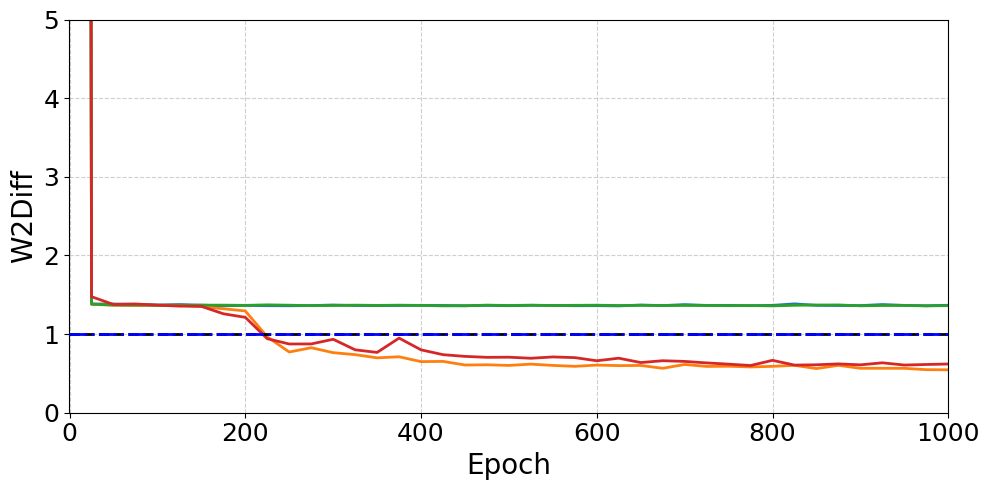

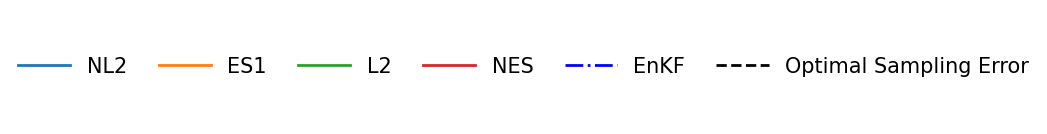

In [5]:
import torch
import os
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
import numpy as np

# =================== Style & layout knobs ===================
FIGSIZE_MAIN = (10, 5)
FIGSIZE_LEGEND = (10, 1.2)

# Line Styles
MAIN_LINE_WIDTH = 2.0

# GT Baseline (inherent uncertainty)
GT_COLOR = "k"
GT_LS = "--"
GT_LW = 2.0
GT_LABEL = "Optimal Sampling Error"

# EnKF Baseline
ENKF_COLOR = "blue"
ENKF_LS = "-."
ENKF_LW = 2.0
ENKF_LABEL = "EnKF"

# Axes ranges and grid
X_LIM = (-0.5, 1000)
Y_LIM = (0, 5)
GRID_LS = "--"
GRID_ALPHA = 0.6

# Font sizes
AXIS_LABEL_FONTSIZE = 20
TICK_FONTSIZE = 18
LEGEND_FONTSIZE = 15

# ===========================================================================

# --- Load Baselines ---
# Manually setting std to 0 implies we only care about the mean lines now
gt_mean = 1
enkf_mean = 1

folder_names = [
    '2025-12-25_15-12lorenz63_1.0_10_60_8192_nl2_joint_EtE-LRes',
    '2025-12-25_15-10lorenz63_1.0_10_60_8192_es_joint_EtE-LRes',
    '2025-12-25_15-12lorenz63_1.0_10_60_8192_l2_joint_EtE-LRes',
    '2025-12-25_15-12lorenz63_1.0_10_60_8192_nes_joint_EtE-LRes'
]
method_names = ['NL2', 'ES1', 'L2', 'NES']

# --- Main figure ---
fig_w2diff, ax_w2diff = plt.subplots(figsize=FIGSIZE_MAIN)

# 1. Plot Training Methods (Mean only)
for i, folder_name in enumerate(folder_names):
    file_name = os.path.join('save', 'lorenz63_EtE_LRes', folder_name, 'training_records.pt')

    if not os.path.exists(file_name):
        print(f"Skipping {folder_name}: File not found.")
        continue

    data = torch.load(file_name, weights_only=True)
    pf_RMSE_curve = np.array(data.get('mean_cov_diff', []))
    epochs = np.array(data.get('test_epochs', []))

    if len(pf_RMSE_curve) == 0:
        continue

    # Plot Mean Line
    ax_w2diff.plot(
        epochs, pf_RMSE_curve,
        linewidth=MAIN_LINE_WIDTH,
        label=method_names[i]
    )
    # Note: fill_between (std shading) removed as requested

# 2. Plot GT Baseline (Horizontal Line only)
ax_w2diff.axhline(
    y=gt_mean, 
    color=GT_COLOR, 
    linestyle=GT_LS, 
    linewidth=GT_LW, 
    label=GT_LABEL, 
    zorder=10
)

# 3. Plot EnKF Baseline (Horizontal Line only)
ax_w2diff.axhline(
    y=enkf_mean, 
    color=ENKF_COLOR, 
    linestyle=ENKF_LS, 
    linewidth=ENKF_LW, 
    label=ENKF_LABEL, 
    zorder=10
)

# Axes cosmetics
ax_w2diff.set_ylabel('W2Diff', fontsize=AXIS_LABEL_FONTSIZE)
ax_w2diff.set_xlabel('Epoch', fontsize=AXIS_LABEL_FONTSIZE)
ax_w2diff.grid(True, which="both", linestyle=GRID_LS, alpha=GRID_ALPHA)
ax_w2diff.set_xlim(*X_LIM)
ax_w2diff.set_ylim(*Y_LIM)
ax_w2diff.tick_params(axis='both', labelsize=TICK_FONTSIZE)
fig_w2diff.tight_layout()

# --- Legend Figure ---
# Order: Methods -> EnKF -> GT (Optimal Sampling Error)
desired_order = method_names + [ENKF_LABEL, GT_LABEL]

handles, labels = ax_w2diff.get_legend_handles_labels()
label_to_handle = {lab: h for h, lab in zip(handles, labels)}

ordered_handles = [label_to_handle[lab] for lab in desired_order if lab in label_to_handle]
ordered_labels = [lab for lab in desired_order if lab in label_to_handle]

fig_legend, ax_legend = plt.subplots(figsize=FIGSIZE_LEGEND)
ax_legend.axis('off')
ax_legend.legend(
    ordered_handles, ordered_labels,
    loc='center',
    ncol=len(ordered_labels),
    frameon=False,
    fontsize=LEGEND_FONTSIZE,
    handlelength=2.5,
    columnspacing=1.5
)
fig_legend.tight_layout(pad=0.2)

# --- Save ---
out_dir = os.path.join("save", "figures")
os.makedirs(out_dir, exist_ok=True)
main_path = os.path.join(out_dir, "linear_gaussian_w2diff_comparison.pdf")
legend_path = os.path.join(out_dir, "linear_gaussian_w2diff_comparison_legend.pdf")

fig_w2diff.savefig(main_path, format="pdf", bbox_inches="tight", pad_inches=0.1)
fig_legend.savefig(legend_path, format="pdf", bbox_inches="tight", pad_inches=0.1)

print(f"Saved to {main_path} and {legend_path}")

plt.show(fig_w2diff)
plt.show(fig_legend)

Saved LR row plot to save/figures/linear_gaussian_w2diff_lr_row.pdf
Saved LR row legend to save/figures/linear_gaussian_w2diff_lr_row_legend.pdf


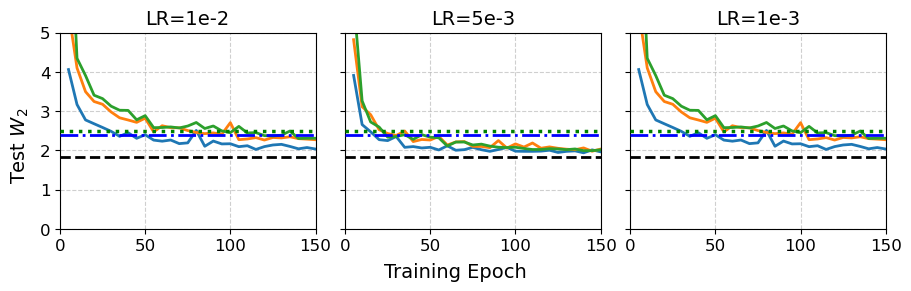

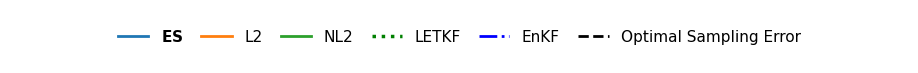

In [6]:
import torch
import os
import matplotlib.pyplot as plt
import numpy as np

# =================== One-row LR comparison ===================
LR_ROW_FIGSIZE = (9.0, 2.8)
LR_ROW_LEGEND_FIGSIZE = (9.0, 0.55)
MAIN_LINE_WIDTH = 2.0

GT_COLOR, GT_LS, GT_LW, GT_LABEL = "k", "--", 2.0, "Optimal Sampling Error"
ENKF_COLOR, ENKF_LS, ENKF_LW, ENKF_LABEL = "blue", "-.", 2.0, "EnKF"
LETKF_COLOR, LETKF_LS, LETKF_LW, LETKF_LABEL = "green", ":", 2.5, "LETKF"

Y_LIM = (0, 5)
X_LIM = (0, 150)
X_TICKS = [0, 50, 100, 150]
GRID_LS = "--"
GRID_ALPHA = 0.6

TITLE_FONTSIZE = 14
AXIS_LABEL_FONTSIZE = 14
TICK_FONTSIZE = 12
LEGEND_FONTSIZE = 11

try:
    gt_mean = benchmark_W2_diff['GT']
    enkf_mean = benchmark_W2_diff['EnKF']
    letkf_mean = benchmark_W2_diff['LETKF']
except NameError:
    print("Warning: Baselines not found, using dummies.")
    gt_mean, enkf_mean, letkf_mean = 0.5, 1.2, 1.5

lr_folder_map_row = {
    "1e-2": [
        '2025-12-25_15-40linear_1_10_60_8192_es_joint_EtE-LRes_20_1e-2',
        '2025-12-25_15-40linear_1_10_60_8192_l2_joint_EtE-LRes_20_1e-2',
        '2025-12-25_15-40linear_1_10_60_8192_nl2_joint_EtE-LRes_20_1e-2'
    ],
    "5e-3": [
        '2025-12-25_15-40linear_1_10_60_8192_es_joint_EtE-LRes_20_5e-3',
        '2025-12-25_15-40linear_1_10_60_8192_l2_joint_EtE-LRes_20_5e-3',
        '2025-12-25_15-40linear_1_10_60_8192_nl2_joint_EtE-LRes_20_5e-3'
    ],
    "1e-3": [
        '2026-01-04_19-49linear_1_10_60_8192_es_joint_EtE-LRes_20_1e-3',
        '2026-01-04_19-49linear_1_10_60_8192_l2_joint_EtE-LRes_20_1e-3',
        '2026-01-04_19-49linear_1_10_60_8192_nl2_joint_EtE-LRes_20_1e-3'
    ]
}

method_names_row = [r'$\mathbf{ES}$', 'L2', 'NL2']
lrs_to_plot_row = ["1e-2", "5e-3", "1e-3"]

fig_lr_row, axes_lr_row = plt.subplots(
    1,
    len(lrs_to_plot_row),
    figsize=LR_ROW_FIGSIZE,
    sharey=True,
    constrained_layout=True
)

for ax, lr in zip(axes_lr_row, lrs_to_plot_row):
    for i, folder_name in enumerate(lr_folder_map_row[lr]):
        file_path = os.path.join('save', 'linear_gaussian_example', folder_name, 'training_records.pt')

        if not os.path.exists(file_path):
            print(f"Missing: {folder_name}")
            continue

        data = torch.load(file_path, weights_only=True, map_location="cpu")
        mean_curve = np.array(data.get('mean_w2_diff', []))
        epochs = np.array(data.get('test_epochs', []))

        if len(mean_curve) == 0 or len(epochs) == 0:
            continue

        epoch_mask = (epochs >= 1) & (epochs <= 150)
        ax.plot(
            epochs[epoch_mask],
            mean_curve[epoch_mask],
            linewidth=MAIN_LINE_WIDTH,
            label=method_names_row[i]
        )

    ax.axhline(y=gt_mean, color=GT_COLOR, ls=GT_LS, lw=GT_LW, label=GT_LABEL, zorder=10)
    ax.axhline(y=enkf_mean, color=ENKF_COLOR, ls=ENKF_LS, lw=ENKF_LW, label=ENKF_LABEL, zorder=10)
    ax.axhline(y=letkf_mean, color=LETKF_COLOR, ls=LETKF_LS, lw=LETKF_LW, label=LETKF_LABEL, zorder=10)

    ax.set_title(f"LR={lr}", fontsize=TITLE_FONTSIZE)
    ax.set_xlim(*X_LIM)
    ax.set_ylim(*Y_LIM)
    ax.set_xticks(X_TICKS)
    ax.grid(True, which="both", linestyle=GRID_LS, alpha=GRID_ALPHA)
    ax.tick_params(axis='both', labelsize=TICK_FONTSIZE)

fig_lr_row.supylabel(r"Test $W_2$", fontsize=AXIS_LABEL_FONTSIZE)
fig_lr_row.supxlabel("Training Epoch", fontsize=AXIS_LABEL_FONTSIZE)

desired_order_row = method_names_row + [LETKF_LABEL, ENKF_LABEL, GT_LABEL]
handles, labels = axes_lr_row[-1].get_legend_handles_labels()
label_to_handle = {lab: h for h, lab in zip(handles, labels)}
ordered_handles = [label_to_handle[lab] for lab in desired_order_row if lab in label_to_handle]
ordered_labels = [lab for lab in desired_order_row if lab in label_to_handle]

fig_lr_row_legend, ax_lr_row_legend = plt.subplots(figsize=LR_ROW_LEGEND_FIGSIZE)
ax_lr_row_legend.axis("off")
ax_lr_row_legend.legend(
    ordered_handles,
    ordered_labels,
    loc="center",
    ncol=len(ordered_labels),
    frameon=False,
    fontsize=LEGEND_FONTSIZE,
    handlelength=2.0,
    columnspacing=1.2
)
fig_lr_row_legend.tight_layout(pad=0.05)

out_dir = os.path.join("save", "figures")
os.makedirs(out_dir, exist_ok=True)
row_path = os.path.join(out_dir, "linear_gaussian_w2diff_lr_row.pdf")
legend_path = os.path.join(out_dir, "linear_gaussian_w2diff_lr_row_legend.pdf")
fig_lr_row.savefig(row_path, format="pdf", bbox_inches="tight", pad_inches=0.1)
fig_lr_row_legend.savefig(legend_path, format="pdf", bbox_inches="tight", pad_inches=0.1)
print(f"Saved LR row plot to {row_path}")
print(f"Saved LR row legend to {legend_path}")

plt.show()
